# 05 – Modelagem Preditiva (Machine Learning)
**Objetivo:** Treinar, otimizar e avaliar modelos de classificação para prever o desfecho de óbito hospitalar (indicador_obito) em pacientes internados por IAM. Faremos a comparação entre modelos lineares e baseados em árvores, seguidos de análise de interpretabilidade.

In [2]:
%pip install xgboost lightgbm shap

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.2 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 11.1 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 11.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 11.1 MB/s  0:00:30m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [shap]7/8 [shap]]t]]cl-cu12]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Interpretability
import shap

import warnings
warnings.filterwarnings('ignore')

FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

/home/carolina/miniconda3/envs/iam/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento e Pré-processamento
Carregaremos a base reduzida (saída do notebook 03). Faremos o tratamento de variáveis categóricas (One-Hot Encoding) e a divisão em Treino/Teste.

In [4]:
DATA_PATH = Path('../data/processed/base_modelagem_reduzida.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir tipo do target
df['indicador_obito'] = df['indicador_obito'].astype(int)

# Separar X e y
X = df.drop(columns=['indicador_obito'])
y = df['indicador_obito']

# One-Hot Encoding para categóricas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# XGBoost e LightGBM não gostam de caracteres especiais nas colunas (como <, > ou [, ])
X_encoded.columns = [re.sub(r'[\[\]<>\s]', '_', col) for col in X_encoded.columns]

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (304472, 158)
Teste:  (76119, 158)


## 2. Tratamento de Desbalanceamento & Baseline
A classe de óbitos é minoritária. Os algoritmos baseados em árvore (XGBoost/LightGBM) possuem parâmetros como `scale_pos_weight` ou `is_unbalance` para lidar com isso nativamente. Para o baseline (Regressão Logística), usaremos `class_weight='balanced'`.

In [5]:
# O Baseline (Logistic Regression) não aceita valores nulos, então vamos imputar a mediana.
# Modelos baseados em árvore (XGBoost/LightGBM) lidam com nulos nativamente.

baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_lr = baseline_pipeline.predict(X_test)
y_prob_lr = baseline_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Para plotar a curva ROC depois, guardaremos a referência do modelo treinado
lr_model = baseline_pipeline

=== Logistic Regression (Baseline) ===
ROC-AUC: 0.9587
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     68937
           1       0.39      0.95      0.55      7182

    accuracy                           0.85     76119
   macro avg       0.69      0.90      0.73     76119
weighted avg       0.94      0.85      0.88     76119



## 3. Modelos Avançados (Tree-based)
Treinamento de XGBoost e LightGBM, que geralmente perforam melhor em dados tabulares sem necessidade de scaling rigoroso.

In [6]:
# Cálculo do peso para lidar com classes desbalanceadas (Altas / Óbitos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Peso aplicado à classe minoritária: {scale_pos_weight:.2f}\n")

# --- XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

# --- LightGBM (parâmetros ajustados para evitar aviso de convergência) ---
lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))


Peso aplicado à classe minoritária: 9.60

=== XGBoost ===
ROC-AUC: 0.9498
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     68937
           1       0.43      0.88      0.57      7182

    accuracy                           0.88     76119
   macro avg       0.71      0.88      0.75     76119
weighted avg       0.93      0.88      0.89     76119

=== LightGBM ===
ROC-AUC: 0.9507
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     68937
           1       0.42      0.88      0.57      7182

    accuracy                           0.88     76119
   macro avg       0.71      0.88      0.75     76119
weighted avg       0.93      0.88      0.89     76119



## 4. Avaliação e Comparação de Modelos
Plotar a Curva ROC comparando os modelos e visualizar as matrizes de confusão.

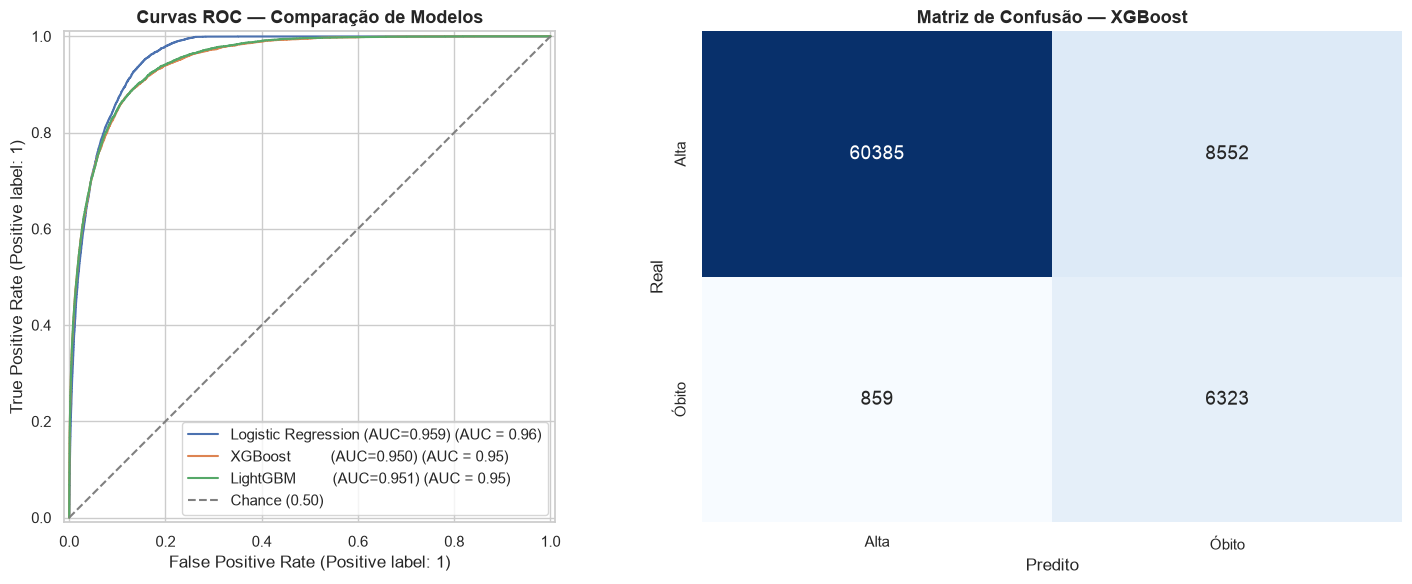

Figura salva em reports/figures/roc_confusion_matrix.png

=== RESUMO COMPARATIVO ===
Modelo                            ROC-AUC   Recall (Óbito)
----------------------------------------------------------
Logistic Regression                0.9587           95.21%
XGBoost                            0.9498           88.04%
LightGBM                           0.9507           88.15%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curvas ROC comparativas
RocCurveDisplay.from_estimator(lr_model,  X_test, y_test, name=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})',  ax=axes[0])
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name=f'XGBoost          (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})', ax=axes[0])
RocCurveDisplay.from_estimator(lgb_model, X_test, y_test, name=f'LightGBM         (AUC={roc_auc_score(y_test, y_prob_lgb):.3f})', ax=axes[0])
axes[0].set_title('Curvas ROC — Comparação de Modelos', fontsize=13, fontweight='bold')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance (0.50)')
axes[0].legend(loc='lower right')

# Matriz de Confusão — XGBoost (melhor modelo)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            annot_kws={'size': 14})
axes[1].set_title('Matriz de Confusão — XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_xticklabels(['Alta', 'Óbito'])
axes[1].set_yticklabels(['Alta', 'Óbito'])

plt.tight_layout()
plt.savefig(FIG_PATH / 'roc_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/roc_confusion_matrix.png")

# Tabela resumo
print("\n=== RESUMO COMPARATIVO ===")
print(f"{'Modelo':<30} {'ROC-AUC':>10} {'Recall (Óbito)':>16}")
print("-" * 58)
from sklearn.metrics import recall_score
for nome, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('XGBoost',            y_pred_xgb, y_prob_xgb),
    ('LightGBM',           y_pred_lgb, y_prob_lgb),
]:
    auc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)
    print(f"{nome:<30} {auc:>10.4f} {rec:>16.2%}")


## 5. Interpretabilidade (SHAP)
Extrair o SHAP summary plot do melhor modelo para entender quais features mais contribuem para o risco de óbito.

Calculando SHAP values (pode levar alguns segundos)...


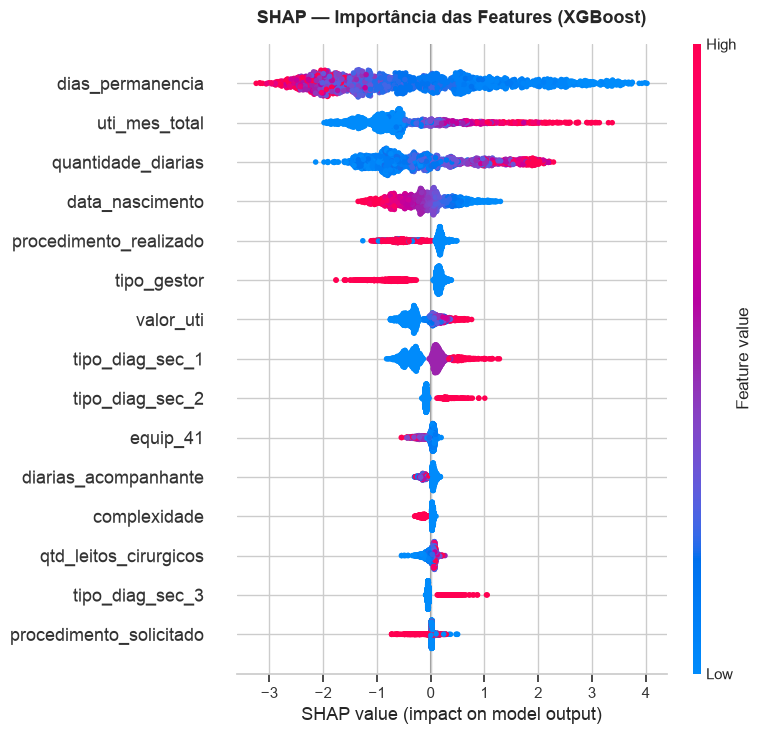

Figura salva em reports/figures/shap_summary_plot.png


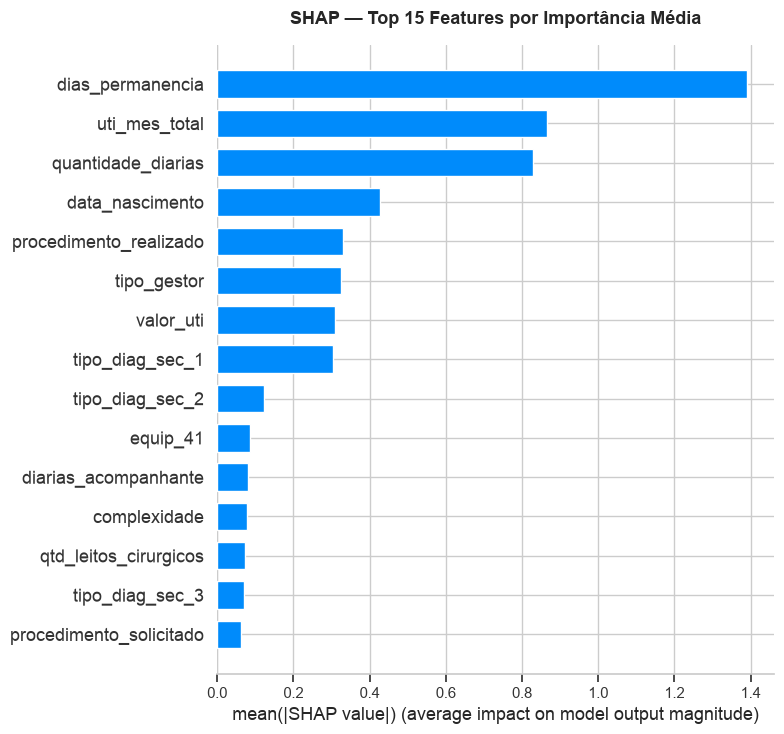

Figura salva em reports/figures/shap_bar_plot.png


In [8]:
# O SHAP explica o impacto de cada variável na predição do XGBoost
print("Calculando SHAP values (pode levar alguns segundos)...")
explainer = shap.TreeExplainer(xgb_model)

# Amostra de 2000 registros para performance
X_shap = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_shap)

# Summary Plot — importância global + direção do efeito
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP — Importância das Features (XGBoost)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/shap_summary_plot.png")

# Bar Plot — importância média absoluta
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Top 15 Features por Importância Média', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/shap_bar_plot.png")
